In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_parameter_sensitivities(
    df: pd.DataFrame,
    outcomes,
    x_col: str = "log10_value",
    nrows: int = 5,
    ncols: int = 3,
    figsize=(14, 18),
    default_yscale: str = "log",          # "log" | "symlog" | "linear"
    symlog_linthresh: float = 1e-6,
    calibrated_x=None,                    # None | float | dict[param->float] | callable(param, sub)->float
    params=None,                          # None (use df order) | list[str] subset/order of parameters

    x_map=None,                           # None | dict[param->xlabel] | callable(param)->str | str
    y_map=None,                           # None | dict[param->title]  | callable(param)->str

    outcome_map=None,                     # NEW: None | dict[outcome->label] | callable(outcome)->str

    marker: str = "o",
    linewidth: float = 1.5,
    markersize: float = 3.0,
    legend_outside: bool = True,
    legend_bbox=(0.885, 0.5),
    legend_loc="center left",
    title: str = "Parameter sensitivity sweeps",
    title_fontsize: int = 16,
    subplot_title_fontsize: int = 11,
    label_fontsize: int = 10,
    tick_fontsize: int = 9,
    grid_alpha: float = 0.2,
    show: bool = True,
    savepath: str | None = None,
):
    outcomes = list(outcomes)

    required_cols = {"parameter", x_col, *outcomes}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in df: {sorted(missing)}")

    if params is None:
        params = df["parameter"].unique().tolist()
    else:
        params = list(params)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)

    legend_handles = legend_labels = None

    def _get_calibrated_x(param, sub, x):
        if calibrated_x is None:
            return 0.5 * (np.nanmin(x) + np.nanmax(x))
        if callable(calibrated_x):
            return float(calibrated_x(param, sub))
        if isinstance(calibrated_x, dict):
            return float(calibrated_x.get(param, 0.5 * (np.nanmin(x) + np.nanmax(x))))
        return float(calibrated_x)

    def _resolve_x_label(param):
        if x_map is None:
            return x_col
        if isinstance(x_map, str):
            return x_map
        if callable(x_map):
            return str(x_map(param))
        if isinstance(x_map, dict):
            return str(x_map.get(param, x_col))
        return x_col

    def _resolve_subplot_title(param):
        if y_map is None:
            return str(param)
        if callable(y_map):
            return str(y_map(param))
        if isinstance(y_map, dict):
            return str(y_map.get(param, str(param)))
        return str(param)

    def _resolve_outcome_label(outcome):
        if outcome_map is None:
            return str(outcome)
        if isinstance(outcome_map, str):
            return outcome_map
        if callable(outcome_map):
            return str(outcome_map(outcome))
        if isinstance(outcome_map, dict):
            return str(outcome_map.get(outcome, str(outcome)))
        return str(outcome)

    for i, p in enumerate(params):
        if i >= nrows * ncols:
            break

        ax = axes[i]
        sub = df[df["parameter"] == p].copy()
        if sub.empty:
            ax.axis("off")
            continue

        x = sub[x_col].to_numpy()
        order = np.argsort(x)
        x = x[order]
        x0 = _get_calibrated_x(p, sub, x)

        for o in outcomes:
            y = sub[o].to_numpy()[order]
            ax.plot(
                x, y,
                marker=marker,
                linewidth=linewidth,
                markersize=markersize,
                label=_resolve_outcome_label(o),   # <-- key change
            )

        ax.axvline(x0, linestyle="--", linewidth=1.2, color="red")

        ax.set_title(_resolve_subplot_title(p), fontsize=subplot_title_fontsize)
        #ax.set_xlabel(_resolve_x_label(p), fontsize=label_fontsize)
        ax.set_xlabel("")
        ax.tick_params(axis="both", labelsize=tick_fontsize)
        ax.grid(True, alpha=grid_alpha)

        y_all = np.concatenate([sub[o].to_numpy() for o in outcomes])
        y_all = y_all[np.isfinite(y_all)]

        if default_yscale == "log":
            if y_all.size and np.all(y_all > 0):
                ax.set_yscale("log")
            else:
                ax.set_yscale("symlog", linthresh=symlog_linthresh)
        elif default_yscale == "symlog":
            ax.set_yscale("symlog", linthresh=symlog_linthresh)
        else:
            ax.set_yscale("linear")

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

    used = min(len(params), nrows * ncols)
    for j in range(used, nrows * ncols):
        axes[j].axis("off")

    if legend_outside and legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox,
            frameon=False,
            title="Outcome",
        )
        right_margin = 0.86
    else:
        right_margin = 0.98

    fig.suptitle(title, fontsize=title_fontsize, y=0.995)
    fig.tight_layout(rect=[0, 0, right_margin, 0.985])

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    if show:
        plt.show()

    return fig, axes


In [3]:
df = pd.read_csv("../Results/sensitivity_sweeps.csv")
df

,parameter,parameter_value,log10_value,total_infected_area,total_virus_AUC,total_infected_AUC,peak_time_virus,peak_virus,peak_time_infection,peak_infection,peak_time_IFN,peak_IFN
0,beta,0.080000,-1.096910,0.367188,42.865257,8.058353,6.4,6.538142,7.5,1.148080,10.0,3.937458
1,beta,0.111160,-0.954053,0.355469,39.825597,8.075319,4.8,6.752423,6.5,1.195556,10.0,15.516439
2,beta,0.154456,-0.811196,0.355469,34.874550,7.490969,4.1,7.020928,4.0,1.262884,10.0,22.626366
3,beta,0.214616,-0.668339,0.339844,29.972094,6.800424,3.5,7.279419,2.9,1.406454,10.0,26.458028
4,beta,0.298207,-0.525481,0.324219,25.773772,6.171409,3.1,7.522355,2.7,1.567413,9.9,30.216592
...,...,...,...,...,...,...,...,...,...,...,...,...
220,K_F,26.826958,1.428571,0.792969,154.333790,27.518508,6.9,22.246591,7.9,4.178655,10.0,1.549833
221,K_F,37.275937,1.571429,0.800781,163.534615,28.019595,8.0,24.109930,7.9,4.346476,10.0,1.095023
222,K_F,51.794747,1.714286,0.804688,167.583612,28.222652,8.0,25.100504,7.8,4.412777,10.0,0.959295
223,K_F,71.968567,1.857143,0.808594,169.522729,28.315872,8.0,25.576403,7.8,4.444973,10.0,0.903411


In [4]:
def compute_effect_sizes(df, outcomes, x_col="log10_value", params=None):
    """
    Returns a DataFrame with effect sizes per (parameter, outcome):
      - fold_log10_range = log10(max(y)/min(y)) over the sweep (requires y>0)
      - rel_range = max(y)/y0 and min(y)/y0 around calibrated point y0 (center of x range)
    """
    outcomes = list(outcomes)
    if params is None:
        params = df["parameter"].unique().tolist()
    else:
        params = list(params)

    rows = []
    for p in params:
        sub = df[df["parameter"] == p].copy()
        if sub.empty:
            continue

        # sort by x
        x = sub[x_col].to_numpy()
        order = np.argsort(x)
        sub = sub.iloc[order].reset_index(drop=True)
        x = sub[x_col].to_numpy()

        # calibrated point = center of sweep in x, choose nearest sample
        x0 = 0.5 * (np.nanmin(x) + np.nanmax(x))
        idx0 = int(np.argmin(np.abs(x - x0)))

        for o in outcomes:
            y = sub[o].to_numpy()
            y = y[np.isfinite(y)]
            if y.size == 0:
                continue

            y0 = sub.loc[idx0, o]
            y_min = np.nanmin(y)
            y_max = np.nanmax(y)

            # fold range (log10) only well-defined if strictly positive
            if np.all(y > 0):
                fold_log10_range = np.log10(y_max / y_min) if y_min > 0 else np.nan
            else:
                fold_log10_range = np.nan

            # relative range around y0 (can work with negatives if y0!=0; still interpret cautiously)
            rel_min = (y_min / y0) if (np.isfinite(y0) and y0 != 0) else np.nan
            rel_max = (y_max / y0) if (np.isfinite(y0) and y0 != 0) else np.nan

            rows.append({
                "parameter": p,
                "outcome": o,
                "fold_log10_range": fold_log10_range,
                "y0": y0,
                "y_min": y_min,
                "y_max": y_max,
                "rel_min": rel_min,
                "rel_max": rel_max,
            })

    eff = pd.DataFrame(rows)
    return eff


In [5]:
def plot_effectsize_heatmap(
    eff: pd.DataFrame,
    value_col: str = "fold_log10_range",
    params_order=None,
    outcomes_order=None,
    title: str = r"Sensitivity summary: $\log_{10}(\max/\min)$ across sweep",
    figsize=(6, 7),
    annotate: bool = True,
    cmap=None,

    x_ticklabels=None,   # None | list[str] aligned with outcomes_order/mat.columns | dict[outcome->str]
    y_ticklabels=None,   # None | list[str] aligned with params_order/mat.index    | dict[param->str]
    x_label: str | None = None,
    y_label: str | None = None,
    cbar_label: str | None = None,

    xtick_rotation: float = 45,
    xtick_ha: str = "right",
    annot_fmt: str = "{:.2f}",
    annot_fontsize: int = 8,
):
    """
    Heatmap of effect sizes with optional custom tick labels and axis labels.

    Parameters
    ----------
    x_ticklabels:
        - None: use outcome names
        - list[str]: must match number/order of heatmap columns
        - dict: maps outcome -> label
    y_ticklabels:
        - None: use parameter names
        - list[str]: must match number/order of heatmap rows
        - dict: maps parameter -> label
    x_label, y_label:
        Axis labels under/left of the heatmap (optional).
    cbar_label:
        Colorbar label. Defaults to value_col if None.
    """
    # Pivot into matrix: rows=params, cols=outcomes
    mat = eff.pivot(index="parameter", columns="outcome", values=value_col)

    if params_order is not None:
        mat = mat.reindex(list(params_order))
    if outcomes_order is not None:
        mat = mat.reindex(columns=list(outcomes_order))

    # Build tick label lists
    col_names = list(mat.columns)
    row_names = list(mat.index)

    def _resolve_labels(names, labels):
        if labels is None:
            return names
        if isinstance(labels, dict):
            return [labels.get(n, str(n)) for n in names]
        # assume list/tuple/np array
        labels = list(labels)
        if len(labels) != len(names):
            raise ValueError(f"Label list length {len(labels)} != number of entries {len(names)}")
        return labels

    xlabels = _resolve_labels(col_names, x_ticklabels)
    ylabels = _resolve_labels(row_names, y_ticklabels)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(mat.to_numpy(), aspect="auto", interpolation="nearest", cmap=cmap)

    ax.set_title(title)

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(xlabels, rotation=xtick_rotation, ha=xtick_ha)

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(ylabels)

    if x_label is not None:
        ax.set_xlabel(x_label)
    if y_label is not None:
        ax.set_ylabel(y_label)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label if cbar_label is not None else value_col)

    if annotate:
        data = mat.to_numpy()
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data[i, j]
                txt = "" if (not np.isfinite(v)) else annot_fmt.format(v)
                ax.text(j, i, txt, ha="center", va="center", fontsize=annot_fontsize)

    fig.tight_layout()
    plt.show()
    return fig, ax


In [6]:
df.columns

Index(['parameter', 'parameter_value', 'log10_value', 'total_infected_area',
       'total_virus_AUC', 'total_infected_AUC', 'peak_time_virus',
       'peak_virus', 'peak_time_infection', 'peak_infection', 'peak_time_IFN',
       'peak_IFN'],
      dtype='str')

In [7]:
outcomes = ['total_infected_area',
       'total_virus_AUC', 'total_infected_AUC', 'peak_time_virus',
       'peak_virus', 'peak_time_infection', 'peak_infection', 'peak_time_IFN',
       'peak_IFN']
eff = compute_effect_sizes(df, outcomes)
eff

,parameter,outcome,fold_log10_range,y0,y_min,y_max,rel_min,rel_max
0,beta,total_infected_area,0.075501,0.308594,0.308594,0.367188,1.000000,1.189873
1,beta,total_virus_AUC,0.395985,18.903841,17.223445,42.865257,0.911108,2.267542
2,beta,total_infected_AUC,0.187248,5.247008,5.247008,8.075319,1.000000,1.539033
3,beta,peak_time_virus,0.660052,2.200000,1.400000,6.400000,0.636364,2.909091
4,beta,peak_virus,0.215416,8.244681,6.538142,10.736683,0.793013,1.302256
...,...,...,...,...,...,...,...,...
130,K_F,peak_virus,1.892658,8.244681,0.330516,25.813708,0.040088,3.130953
131,K_F,peak_time_infection,0.818446,2.100000,1.200000,7.900000,0.571429,3.761905
132,K_F,peak_infection,0.877445,2.154107,0.591468,4.460427,0.274577,2.070661
133,K_F,peak_time_IFN,0.275724,7.400000,5.300000,10.000000,0.716216,1.351351


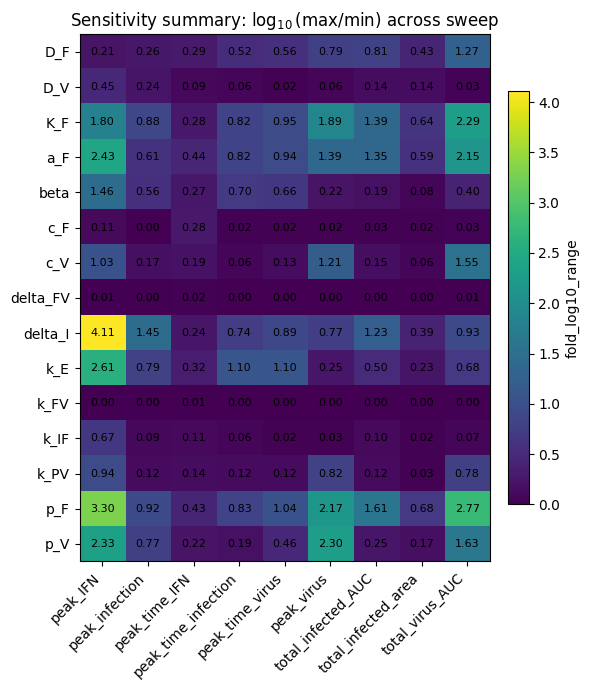

(<Figure size 600x700 with 2 Axes>,
 <Axes: title={'center': 'Sensitivity summary: $\\log_{10}(\\max/\\min)$ across sweep'}>)

In [8]:
plot_effectsize_heatmap(eff, value_col="fold_log10_range")


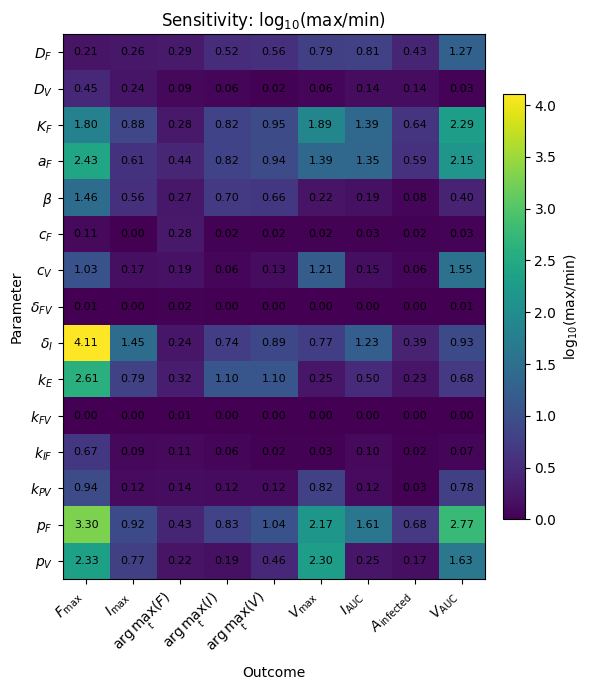

In [9]:
y_map = {
    "beta":     r"$\beta$",
    "k_E":      r"$k_E$",
    "delta_I":  r"$\delta_I$",
    "p_V":      r"$p_V$",
    "c_V":      r"$c_V$",
    "D_V":      r"$D_V$",
    "p_F":      r"$p_F$",
    "c_F":      r"$c_F$",
    "D_F":      r"$D_F$",
    "k_FV":     r"$k_{FV}$",
    "k_IF":     r"$k_{IF}$",
    "a_F":      r"$a_F$",
    "K_F":      r"$K_F$",
    "k_PV": r"$k_{PV}$",
    "delta_FV": r"$\delta_{FV}$"
}

x_map = {
    "total_infected_area": r"$A_{\mathrm{infected}}$",
    "total_virus_AUC": r"$V_{\mathrm{AUC}}$",
    "total_infected_AUC": r"$I_{\mathrm{AUC}}$",
    "peak_virus": r"$V_{\max}$",
    "peak_IFN": r"$F_{\max}$",
    "peak_infection":r"$I_{\max}$",
    "peak_time_virus":r"$\arg \max_t (V)$",
    "peak_time_infection":r"$\arg \max_t (I)$",
    "peak_time_IFN":r"$\arg \max_t (F)$",
}

fig, ax = plot_effectsize_heatmap(
    eff,
    value_col="fold_log10_range",
    title=r"Sensitivity: $\log_{10}\!\left(\max/\min\right)$",
    x_ticklabels=x_map,
    y_ticklabels=y_map,
    x_label="Outcome",
    y_label="Parameter",
    cbar_label=r"$\log_{10}\!\left(\max/\min\right)$",
)

fig.savefig("../Images/SensitivityHeatmap.png",dpi=200)

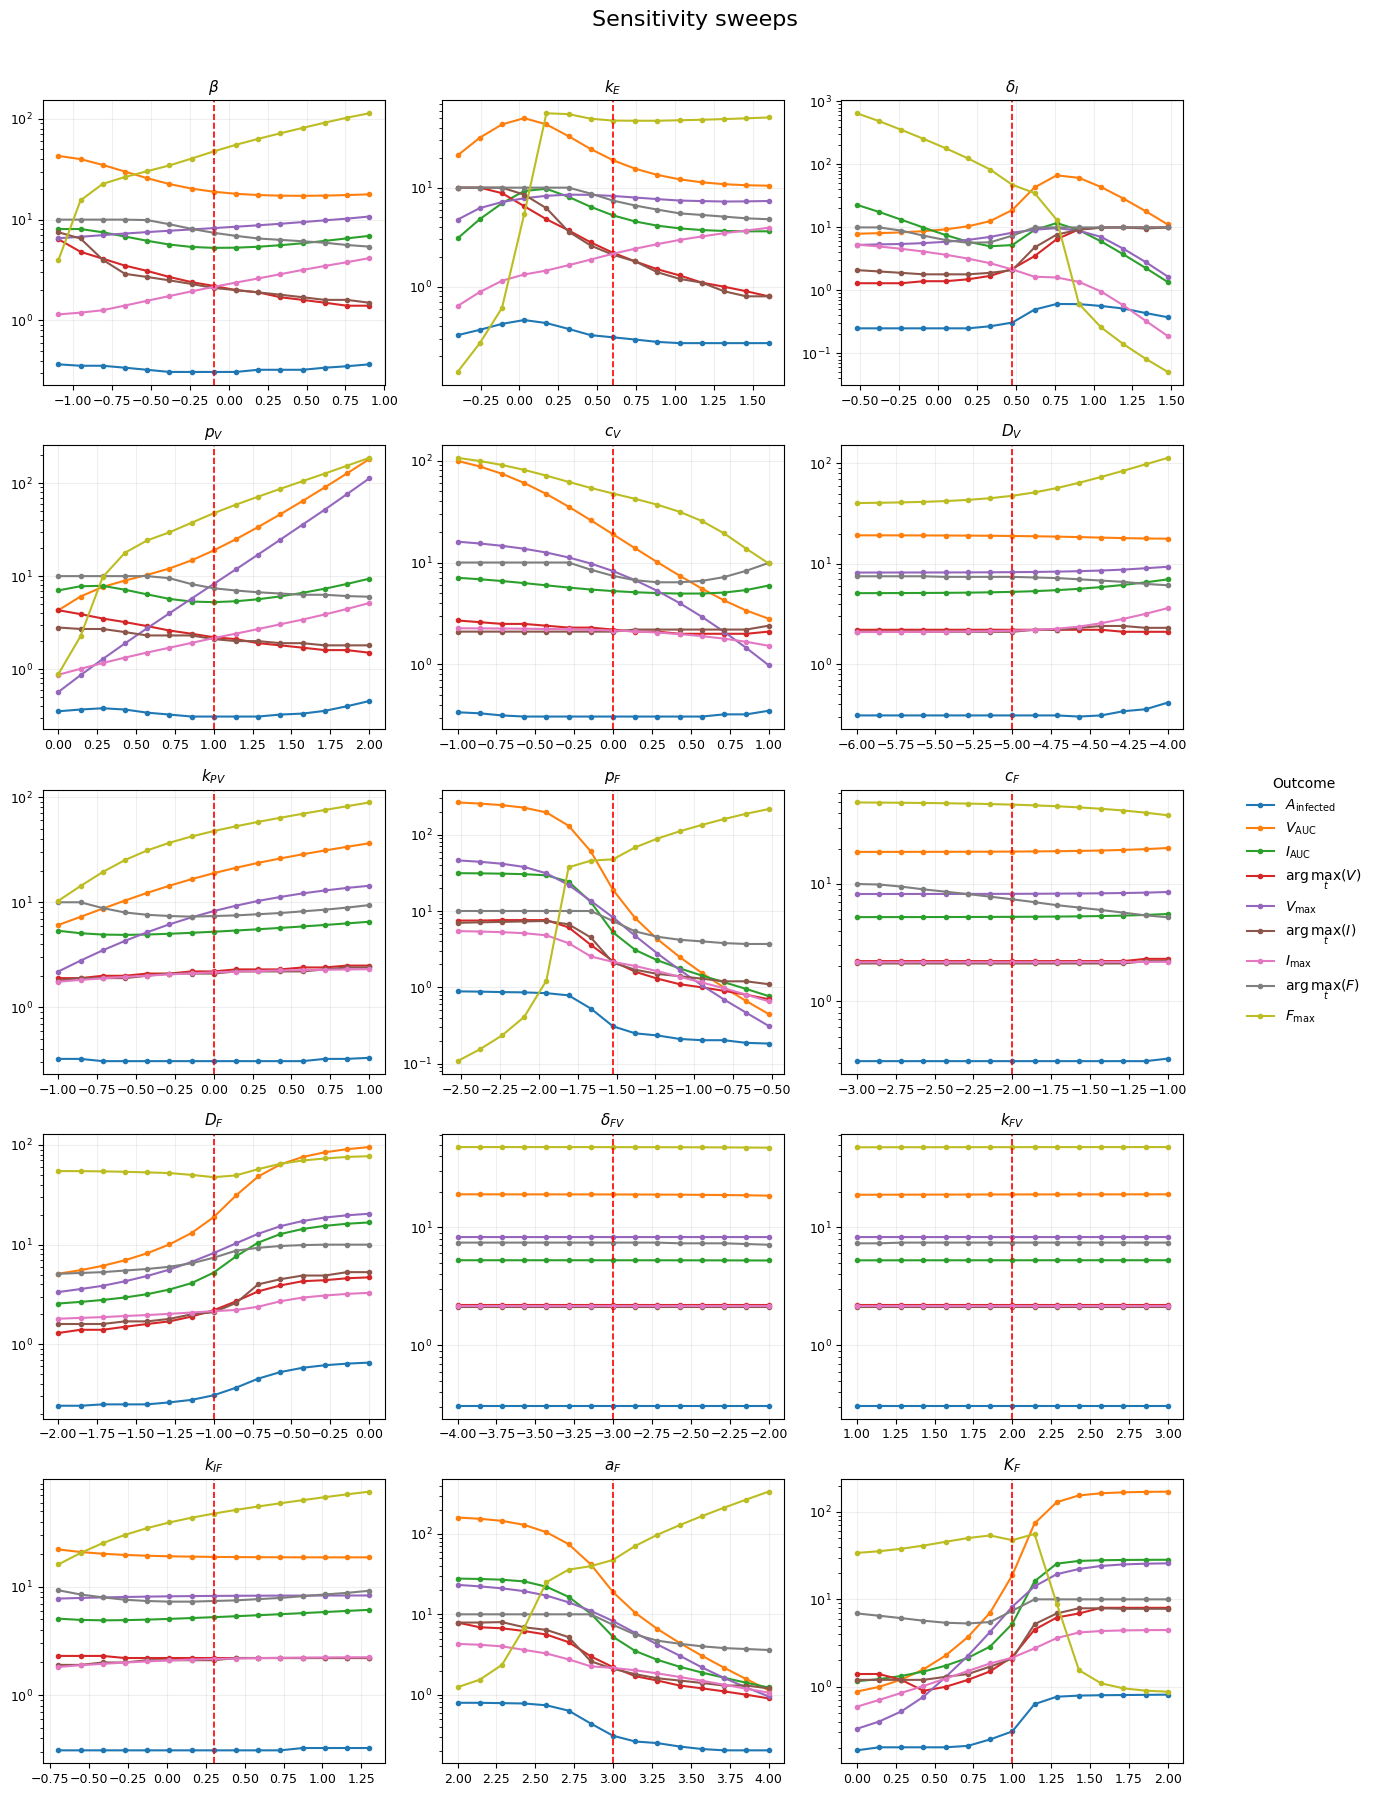

In [10]:
#x_map = {p: rf"$\log_{{10}}({y_map.get(p, p)})$" for p in df["parameter"].unique()}

fig, axs = plot_parameter_sensitivities(
    df,
    outcomes=outcomes,
    x_col="log10_value",
    nrows=5, ncols=3,
    y_map=y_map,
    x_map=x_map,
    outcome_map=x_map,
    legend_bbox=(0.885, 0.5),
    title="Sensitivity sweeps",
)

fig.savefig("../Images/SensitivitySweeps.png",dpi=200)